# Momento de imagen

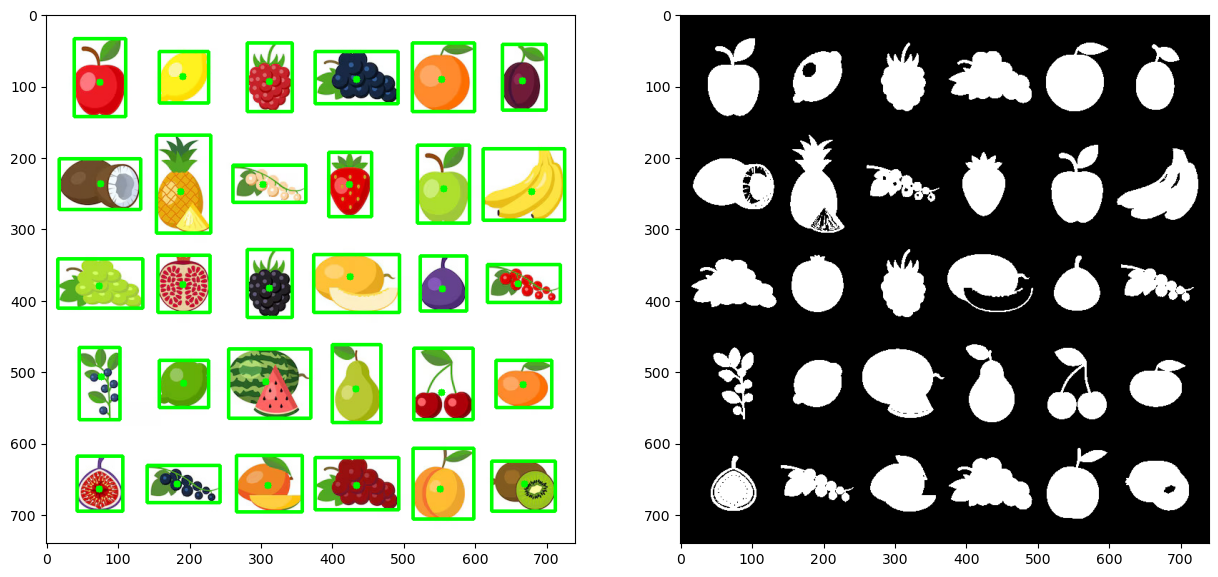

Contorno 1: Perimetro: 383.3624783754349, Area: 2312.0
Contorno 2: Perimetro: 264.69343197345734, Area: 4388.5
Contorno 3: Perimetro: 411.98989486694336, Area: 5130.0
Contorno 4: Perimetro: 237.96551072597504, Area: 3011.0
Contorno 5: Perimetro: 308.0071395635605, Area: 4523.5
Contorno 6: Perimetro: 379.5634882450104, Area: 4712.0
Contorno 7: Perimetro: 266.4507907629013, Area: 3387.0
Contorno 8: Perimetro: 235.23758852481842, Area: 3556.5
Contorno 9: Perimetro: 382.0904006958008, Area: 7312.5
Contorno 10: Perimetro: 551.2863577604294, Area: 3399.5
Contorno 11: Perimetro: 601.1269769668579, Area: 2267.0
Contorno 12: Perimetro: 349.94826424121857, Area: 4370.5
Contorno 13: Perimetro: 384.776692032814, Area: 2316.5
Contorno 14: Perimetro: 407.84775960445404, Area: 5061.0
Contorno 15: Perimetro: 238.79393684864044, Area: 3009.0
Contorno 16: Perimetro: 261.6223633289337, Area: 4296.0
Contorno 17: Perimetro: 610.8427066802979, Area: 4900.0
Contorno 18: Perimetro: 364.5340509414673, Area: 35

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('./images/fruits.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, bin = cv2.threshold(img_gray, 230, 255, cv2.THRESH_BINARY_INV)
contorno, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
perimetros = []
areas = []

for i in range(len(contorno)):
  cnt = contorno[i]
  M = cv2.moments(cnt)
  
  if (M['m00'] != 0):
    # Valores enteros para el centroide
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
  else:
    cx, cy = 0, 0

  area = cv2.contourArea(cnt)
  perimetro = cv2.arcLength(cnt, True)

  if area < 1000:
    continue
  
  perimetros.append(perimetro)
  areas.append(area)

  cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
  
  x, y, w, h = cv2.boundingRect(cnt)
  cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.imshow(bin, cmap='gray')
plt.show()

for i, (perimetro, area) in enumerate(zip(perimetros, areas)):
  print(f"Contorno {i+1}: Perimetro: {perimetro}, Area: {area}")